<a href="https://colab.research.google.com/github/venkata18167/CSA6102-DIGITAL-FORENSICS-AND-CYBERCRIME-INVESTIGATION/blob/main/15_exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload sample files...


Saving sample(1).txt to sample(1).txt

Generated Hashes
        Filename                               MD5  \
0  sample(1).txt  1755a17d4bf7bbdac998321148c7f895   

                                       SHA1  \
0  3e4b221daa48ed315c0f22fc21b2428adc3b93bb   

                                              SHA256  
0  26ab3dcf8725d43a54d0bb8eb002cf25f26a3d281fc4bf...  

CSV Saved: malware_hash_database.csv

Malware Detection Results
----------------------------------------
sample(1).txt  --> Clean File

Detection Statistics
--------------------
Total Files       : 1
Malware Detected  : 0
Clean Files       : 1
Detection Rate    : 0.00%

Hash Family Clustering
  Hash Family  Count
0         MD5      1
1        SHA1      1
2      SHA256      1


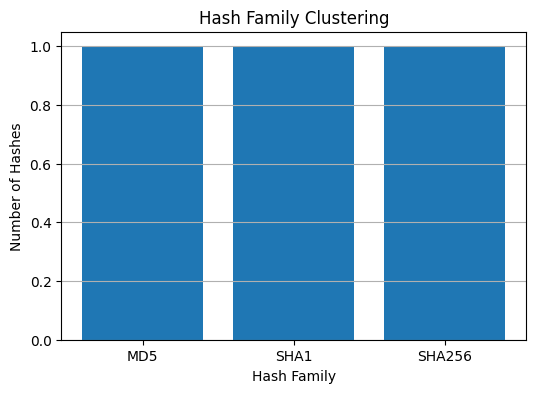

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Experiment Completed Successfully!


In [1]:

import hashlib
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

print("Upload sample files...")
uploaded = files.upload()

def calculate_hashes(filename):

    md5 = hashlib.md5()
    sha1 = hashlib.sha1()
    sha256 = hashlib.sha256()

    with open(filename, "rb") as file:

        while True:
            chunk = file.read(4096)

            if not chunk:
                break

            md5.update(chunk)
            sha1.update(chunk)
            sha256.update(chunk)

    return md5.hexdigest(), sha1.hexdigest(), sha256.hexdigest()

records = []

for filename in uploaded.keys():

    md5, sha1, sha256 = calculate_hashes(filename)

    records.append({
        "Filename": filename,
        "MD5": md5,
        "SHA1": sha1,
        "SHA256": sha256
    })

df = pd.DataFrame(records)

print("\nGenerated Hashes")
print(df)

csv_name = "malware_hash_database.csv"
df.to_csv(csv_name, index=False)

print("\nCSV Saved:", csv_name)

known_hashes = {
    "44d88612fea8a8f36de82e1278abb02f": "EICAR Test File",
    "5d41402abc4b2a76b9719d911017c592": "Trojan",

    "098f6bcd4621d373cade4e832627b4f6": "Backdoor"

}

print("\nMalware Detection Results")
print("-" * 40)

detected = 0

for index, row in df.iterrows():

    if row["MD5"] in known_hashes:

        print(row["Filename"], " --> Malware Detected:", known_hashes[row["MD5"]])
        detected += 1

    else:

        print(row["Filename"], " --> Clean File")

total = len(df)
clean = total - detected

print("\nDetection Statistics")
print("--------------------")
print("Total Files       :", total)
print("Malware Detected  :", detected)
print("Clean Files       :", clean)

if total > 0:
    detection_rate = (detected / total) * 100
else:
    detection_rate = 0

print("Detection Rate    : %.2f%%" % detection_rate)

cluster = pd.DataFrame({
    "Hash Family": ["MD5", "SHA1", "SHA256"],
    "Count": [len(df), len(df), len(df)]
})

print("\nHash Family Clustering")
print(cluster)

plt.figure(figsize=(6,4))
plt.bar(cluster["Hash Family"], cluster["Count"])
plt.title("Hash Family Clustering")
plt.xlabel("Hash Family")
plt.ylabel("Number of Hashes")
plt.grid(axis='y')
plt.show()

files.download(csv_name)

print("\nExperiment Completed Successfully!")